## Cognitus Lite for Finance

Colab-ready notebook for the Cognitive AI final project using the provided DJIA news and price datasets.

**What this notebook does:**
- studies the data carefully
- builds sentiment and market-context features
- trains an auxiliary market-direction model aligned with the dataset
- implements content-based, collaborative, context-aware, and hybrid recommendation
- evaluates both prediction and recommendation quality

In [1]:
# Cell 1 - Install optional packages
# Installs lightweight packages used in the notebook. Safe to skip if they are already available.

# In Colab this should run quickly.
!pip -q install textblob scikit-learn matplotlib seaborn

In [2]:
# Cell 2 - Import libraries
# Loads the libraries used for data handling, NLP, modeling, plotting, and recommendation.

import ast
import html
import os
import re
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)
np.random.seed(42)
random.seed(42)

In [3]:
# Cell 3 - Load the provided datasets
# Reads the three CSV files exactly as given in the project brief.

# Update these paths only if your files are stored elsewhere in Colab.
PATH_COMBINED = "/content/Combined_News_DJIA.csv"
PATH_DJIA = "/content/upload_DJIA_table.csv"
PATH_REDDIT = "/content/RedditNews.csv"

combined_news = pd.read_csv(PATH_COMBINED)
djia_prices = pd.read_csv(PATH_DJIA)
reddit_news = pd.read_csv(PATH_REDDIT)

print("Combined_News_DJIA:", combined_news.shape)
print("upload_DJIA_table:", djia_prices.shape)
print("RedditNews:", reddit_news.shape)

Combined_News_DJIA: (1989, 27)
upload_DJIA_table: (1989, 7)
RedditNews: (73608, 2)


In [4]:
# Cell 4 - Data overview and schema check
# Shows column structure, date coverage, missing values, and label balance so we understand the datasets before modeling.

for df_name, df in {
    "combined_news": combined_news,
    "djia_prices": djia_prices,
    "reddit_news": reddit_news
}.items():
    print(f"\n===== {df_name} =====")
    print(df.head(2))
    print("\nColumns:", list(df.columns))
    print("Shape:", df.shape)
    print("Missing values:\n", df.isna().sum().head(10))

combined_news["Date"] = pd.to_datetime(combined_news["Date"])
djia_prices["Date"] = pd.to_datetime(djia_prices["Date"])
reddit_news["Date"] = pd.to_datetime(reddit_news["Date"])

print("\nDate ranges:")
print("Combined:", combined_news["Date"].min(), "to", combined_news["Date"].max())
print("DJIA:", djia_prices["Date"].min(), "to", djia_prices["Date"].max())
print("Reddit:", reddit_news["Date"].min(), "to", reddit_news["Date"].max())

print("\nLabel distribution in Combined_News_DJIA:")
print(combined_news["Label"].value_counts())
print(combined_news["Label"].value_counts(normalize=True).round(3))


===== combined_news =====
         Date  Label  \
0  2008-08-08      0   
1  2008-08-11      1   

                                                                                            Top1  \
0                     b"Georgia 'downs two Russian warplanes' as countries move to brink of war"   
1  b'Why wont America and Nato help us? If they wont help us now, why did we help them in Iraq?'   

                                          Top2  \
0      b'BREAKING: Musharraf to be impeached.'   
1  b'Bush puts foot down on Georgian conflict'   

                                                                                          Top3  \
0  b'Russia Today: Columns of troops roll into South Ossetia; footage from fighting (YouTube)'   
1           b"Jewish Georgian minister: Thanks to Israeli training, we're fending off Russia "   

                                                                                                                                          Top4  \
0  b'Ru

In [5]:
# Cell 5 - Decode the Top1 to Top25 headlines cleanly
# The combined dataset stores headlines with byte-string artifacts like b'...'. This cell decodes them into normal readable text.

top_cols = [f"Top{i}" for i in range(1, 26)]

def decode_bytes_text(x):
    x = str(x)
    if x.startswith("b'") or x.startswith('b"'):
        try:
            x = ast.literal_eval(x).decode("utf-8", errors="ignore")
        except Exception:
            x = x[2:-1]
    x = html.unescape(x)
    x = x.replace("\\n", " ").replace("\\t", " ")
    return x.strip()

for col in top_cols:
    combined_news[col] = combined_news[col].apply(decode_bytes_text)

combined_news[top_cols].head(2)

,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,Top9,Top10,...,Top16,Top17,Top18,Top19,Top20,Top21,Top22,Top23,Top24,Top25
0,Georgia 'downs two Russian warplanes' as countries move to brink of war,BREAKING: Musharraf to be impeached.,Russia Today: Columns of troops roll into South Ossetia; footage from fighting (YouTube),"Russian tanks are moving towards the capital of South Ossetia, which has reportedly been completely destroyed by Georgian artillery fire","Afghan children raped with 'impunity,' U.N. official says - this is sick, a three year old was raped and they do nothing",150 Russian tanks have entered South Ossetia whilst Georgia shoots down two Russian jets.,"Breaking: Georgia invades South Ossetia, Russia warned it would intervene on SO's side","The 'enemy combatent' trials are nothing but a sham: Salim Haman has been sentenced to 5 1/2 years, but will be kept longer anyway just because they feel like it.","Georgian troops retreat from S. Osettain capital, presumably leaving several hundred people killed. [VIDEO]",Did the U.S. Prep Georgia for War with Russia?,...,"Georgia Invades South Ossetia - if Russia gets involved, will NATO absorb Georgia and unleash a full scale war?",Al-Qaeda Faces Islamist Backlash,"Condoleezza Rice: ""The US would not act to prevent an Israeli strike on Iran."" Israeli Defense Minister Ehud Barak: ""Israel is prepared for uncompromising victory in the case of military hostiliti...",This is a busy day: The European Union has approved new sanctions against Iran in protest at its nuclear programme.,"Georgia will withdraw 1,000 soldiers from Iraq to help fight off Russian forces in Georgia's breakaway region of South Ossetia",Why the Pentagon Thinks Attacking Iran is a Bad Idea - US News & World Report,Caucasus in crisis: Georgia invades South Ossetia,"Indian shoe manufactory - And again in a series of ""you do not like your work?""",Visitors Suffering from Mental Illnesses Banned from Olympics,No Help for Mexico's Kidnapping Surge
1,"Why wont America and Nato help us? If they wont help us now, why did we help them in Iraq?",Bush puts foot down on Georgian conflict,"Jewish Georgian minister: Thanks to Israeli training, we're fending off Russia",Georgian army flees in disarray as Russians advance - Gori abandoned to Russia without a shot fired,Olympic opening ceremony fireworks 'faked',What were the Mossad with fraudulent New Zealand Passports doing in Iraq?,Russia angered by Israeli military sale to Georgia,An American citizen living in S.Ossetia blames U.S. and Georgian leaders for the genocide of innocent people,Welcome To World War IV! Now In High Definition!,"Georgia's move, a mistake of monumental proportions",...,Israel and the US behind the Georgian aggression?,"""Do not believe TV, neither Russian nor Georgian. There are much more victims""",Riots are still going on in Montreal (Canada) because police murdered a boy on Saturday.,China to overtake US as largest manufacturer,War in South Ossetia [PICS],Israeli Physicians Group Condemns State Torture,Russia has just beaten the United States over the head with Peak Oil,Perhaps *the* question about the Georgia - Russia conflict,Russia is so much better at war,So this is what it's come to: trading sex for food.


In [6]:
# Cell 6 - Build one daily document per trading day
# Combines the 25 headlines into one document per day. This is the best text unit for this dataset because the label is also daily.

combined_news["raw_text"] = combined_news[top_cols].agg(" ".join, axis=1)
combined_news["headline_count"] = combined_news[top_cols].notna().sum(axis=1)

daily_news = combined_news[["Date", "Label", "raw_text", "headline_count"]].copy()
daily_news.head()

,Date,Label,raw_text,headline_count
0,2008-08-08,0,Georgia 'downs two Russian warplanes' as countries move to brink of war BREAKING: Musharraf to be impeached. Russia Today: Columns of troops roll into South Ossetia; footage from fighting (YouTube...,25
1,2008-08-11,1,"Why wont America and Nato help us? If they wont help us now, why did we help them in Iraq? Bush puts foot down on Georgian conflict Jewish Georgian minister: Thanks to Israeli training, we're fend...",25
2,2008-08-12,0,"Remember that adorable 9-year-old who sang at the opening ceremonies? That was fake, too. Russia 'ends Georgia operation' ""If we had no sexual harassment we would have no children..."" Al-Qa'eda is...",25
3,2008-08-13,0,"U.S. refuses Israel weapons to attack Iran: report When the president ordered to attack Tskhinvali [the capital of South Ossetia], we knew then we were doomed. How come he didn't realize that? Isr...",25
4,2008-08-14,1,All the experts admit that we should legalise drugs War in South Osetia - 89 pictures made by a Russian soldier. Swedish wrestler Ara Abrahamian throws away medal in Olympic hissy fit Russia exagg...,25


In [7]:
# Cell 7 - Merge daily news with DJIA prices
# Joins the daily headlines with the matching DJIA trading-day data so we can engineer market context and recommendation features.

full_df = daily_news.merge(djia_prices, on="Date", how="inner").sort_values("Date").reset_index(drop=True)

print("Merged shape:", full_df.shape)
full_df.head(3)

Merged shape: (1989, 10)


,Date,Label,raw_text,headline_count,Open,High,Low,Close,Volume,Adj Close
0,2008-08-08,0,Georgia 'downs two Russian warplanes' as countries move to brink of war BREAKING: Musharraf to be impeached. Russia Today: Columns of troops roll into South Ossetia; footage from fighting (YouTube...,25,11432.089844,11759.959961,11388.040039,11734.320312,212830000,11734.320312
1,2008-08-11,1,"Why wont America and Nato help us? If they wont help us now, why did we help them in Iraq? Bush puts foot down on Georgian conflict Jewish Georgian minister: Thanks to Israeli training, we're fend...",25,11729.669922,11867.110352,11675.530273,11782.349609,183190000,11782.349609
2,2008-08-12,0,"Remember that adorable 9-year-old who sang at the opening ceremonies? That was fake, too. Russia 'ends Georgia operation' ""If we had no sexual harassment we would have no children..."" Al-Qa'eda is...",25,11781.700195,11782.349609,11601.519531,11642.469727,173590000,11642.469727


In [8]:
# Cell 8 - Engineer market features and create leakage-safe predictors
# Creates return, volatility, volume, and market-state features for recommendation.
# It also creates lagged numeric versions used by the auxiliary classifier so only past market data is used.

full_df["return_oc"] = (full_df["Close"] - full_df["Open"]) / full_df["Open"]
full_df["return_cc"] = full_df["Close"].pct_change().fillna(0)
full_df["hl_spread"] = (full_df["High"] - full_df["Low"]) / full_df["Open"]
full_df["volume_change"] = full_df["Volume"].pct_change().replace([np.inf, -np.inf], 0).fillna(0)

for w in [3, 5, 10]:
    full_df[f"roll_return_mean_{w}"] = full_df["return_oc"].rolling(w).mean().fillna(0)
    full_df[f"roll_return_std_{w}"] = full_df["return_oc"].rolling(w).std().fillna(0)

# Current-day context used by the recommender
full_df["market_mode"] = np.where(
    full_df["roll_return_mean_5"] > 0.001, "bullish",
    np.where(full_df["roll_return_mean_5"] < -0.001, "bearish", "neutral")
)

vol_low = full_df["roll_return_std_10"].quantile(0.33)
vol_high = full_df["roll_return_std_10"].quantile(0.66)

def risk_bucket(v):
    if v <= vol_low:
        return "low"
    elif v <= vol_high:
        return "medium"
    return "high"

full_df["risk_level"] = full_df["roll_return_std_10"].apply(risk_bucket)

# Lagged numeric features used by the predictive model to avoid same-day leakage
predictor_base_cols = [
    "Open", "High", "Low", "Close", "Volume", "Adj Close",
    "return_oc", "return_cc", "hl_spread", "volume_change",
    "roll_return_mean_3", "roll_return_std_3",
    "roll_return_mean_5", "roll_return_std_5",
    "roll_return_mean_10", "roll_return_std_10"
]

for col in predictor_base_cols:
    full_df[f"{col}_lag1"] = full_df[col].shift(1)

full_df[predictor_base_cols] = full_df[predictor_base_cols].fillna(0)
lagged_cols = [f"{col}_lag1" for col in predictor_base_cols]
full_df[lagged_cols] = full_df[lagged_cols].fillna(0)

full_df[[
    "Date", "Label", "return_oc", "roll_return_mean_5", "roll_return_std_10",
    "market_mode", "risk_level", "return_oc_lag1", "roll_return_mean_5_lag1"
]].head()

,Date,Label,return_oc,roll_return_mean_5,roll_return_std_10,market_mode,risk_level,return_oc_lag1,roll_return_mean_5_lag1
0,2008-08-08,0,0.026437,0.00000,0.0,neutral,low,0.000000,0.0
1,2008-08-11,1,0.004491,0.00000,0.0,neutral,low,0.026437,0.0
2,2008-08-12,0,-0.011818,0.00000,0.0,neutral,low,0.004491,0.0
3,2008-08-13,0,-0.008583,0.00000,0.0,neutral,low,-0.011818,0.0
4,2008-08-14,1,0.007272,0.00356,0.0,bullish,low,-0.008583,0.0


In [9]:
# Cell 9 - Clean the daily text for NLP
# Builds a simple clean text field for TF-IDF. This keeps useful finance terms while removing obvious noise.

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

full_df["clean_text"] = full_df["raw_text"].apply(clean_text)
full_df[["raw_text", "clean_text"]].head(1)

,raw_text,clean_text
0,Georgia 'downs two Russian warplanes' as countries move to brink of war BREAKING: Musharraf to be impeached. Russia Today: Columns of troops roll into South Ossetia; footage from fighting (YouTube...,georgia downs two russian warplanes as countries move to brink of war breaking musharraf to be impeached russia today columns of troops roll into south ossetia footage from fighting youtube russia...


In [10]:
# Cell 10 - Build sentiment features from the headlines
# Uses TextBlob to create polarity and subjectivity scores. These are not the market label; they are sentiment signals used by the recommender.

full_df["sentiment_score"] = full_df["raw_text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
full_df["subjectivity_score"] = full_df["raw_text"].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

def sentiment_bucket(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    return "neutral"

full_df["sentiment_class"] = full_df["sentiment_score"].apply(sentiment_bucket)

print(full_df["sentiment_class"].value_counts())
full_df[["Date", "sentiment_score", "subjectivity_score", "sentiment_class"]].head()

sentiment_class
neutral     1209
positive     611
negative     169
Name: count, dtype: int64


,Date,sentiment_score,subjectivity_score,sentiment_class
0,2008-08-08,-0.048568,0.267549,neutral
1,2008-08-11,0.121956,0.374806,positive
2,2008-08-12,-0.046530,0.518785,neutral
3,2008-08-13,0.011398,0.364021,neutral
4,2008-08-14,0.040677,0.375099,neutral


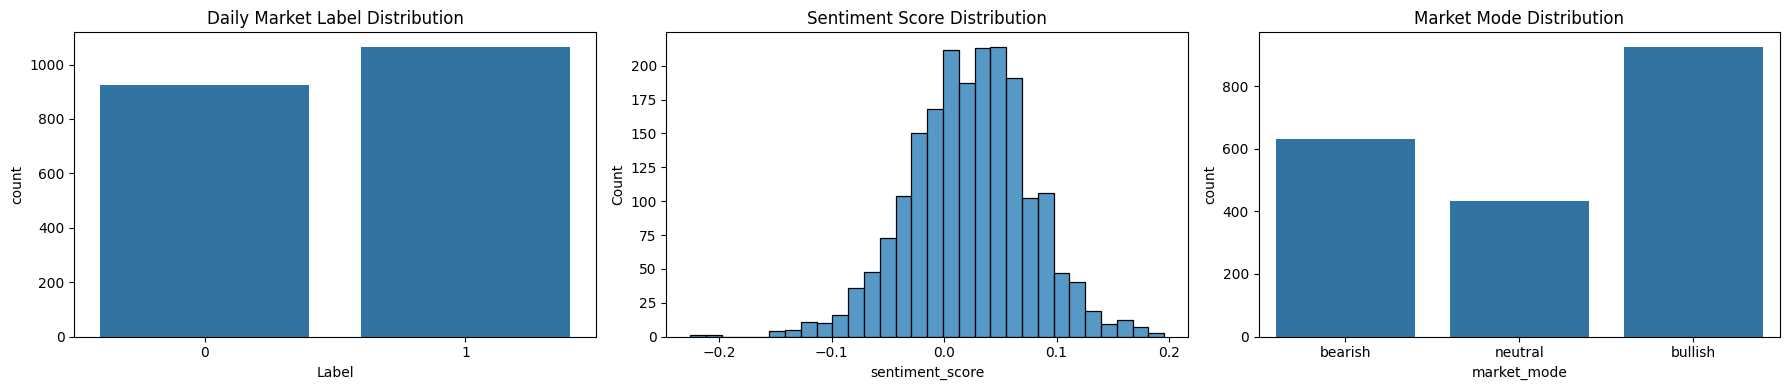

In [11]:
# Cell 11 - Explore the data visually
# Plots the most important distributions so we can see label balance, sentiment spread, and market context clearly.

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(x="Label", data=full_df, ax=axes[0])
axes[0].set_title("Daily Market Label Distribution")

sns.histplot(full_df["sentiment_score"], bins=30, ax=axes[1])
axes[1].set_title("Sentiment Score Distribution")

sns.countplot(x="market_mode", data=full_df, ax=axes[2], order=["bearish", "neutral", "bullish"])
axes[2].set_title("Market Mode Distribution")

plt.tight_layout()
plt.show()

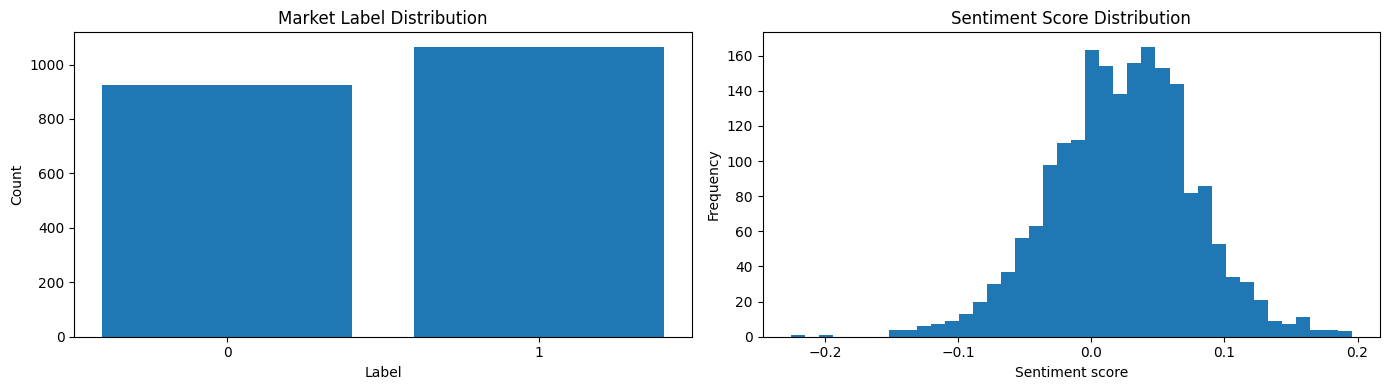

Label distribution:
Label
0     924
1    1065
Name: count, dtype: int64

Sentiment summary:
count    1989.000000
mean        0.022766
std         0.053554
min        -0.225978
25%        -0.011461
50%         0.025092
75%         0.057980
max         0.195774
Name: sentiment_score, dtype: float64


In [12]:
# Cell 11B - Inspect label balance and sentiment distribution
# Adds two quick visuals that help explain the data in the report: class balance for the market label and the overall sentiment distribution.

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

label_counts = full_df["Label"].value_counts().sort_index()
ax[0].bar(label_counts.index.astype(str), label_counts.values)
ax[0].set_title("Market Label Distribution")
ax[0].set_xlabel("Label")
ax[0].set_ylabel("Count")

ax[1].hist(full_df["sentiment_score"], bins=40)
ax[1].set_title("Sentiment Score Distribution")
ax[1].set_xlabel("Sentiment score")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print("Label distribution:")
print(label_counts)
print("\nSentiment summary:")
print(full_df["sentiment_score"].describe())

In [13]:
# Cell 12 - Prepare a realistic temporal train-test split
# Splits by time instead of random shuffle. This is more realistic for financial data and avoids leaking future information into training.

split_idx = int(len(full_df) * 0.8)
train_df = full_df.iloc[:split_idx].copy().reset_index(drop=True)
test_df = full_df.iloc[split_idx:].copy().reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train date range:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Test date range:", test_df["Date"].min(), "to", test_df["Date"].max())

Train shape: (1591, 42)
Test shape: (398, 42)
Train date range: 2008-08-08 00:00:00 to 2014-12-02 00:00:00
Test date range: 2014-12-03 00:00:00 to 2016-07-01 00:00:00


In [14]:
# Cell 13 - Train a leakage-safe auxiliary market-direction model
# Uses daily text plus lagged market features so the classifier only sees past market information.
# This model supports the recommender with confidence scores rather than acting as the final system by itself.

numeric_cols = [
    "sentiment_score",
    "subjectivity_score",
    "Open_lag1", "High_lag1", "Low_lag1", "Close_lag1", "Volume_lag1", "Adj Close_lag1",
    "return_oc_lag1", "return_cc_lag1", "hl_spread_lag1", "volume_change_lag1",
    "roll_return_mean_3_lag1", "roll_return_std_3_lag1",
    "roll_return_mean_5_lag1", "roll_return_std_5_lag1",
    "roll_return_mean_10_lag1", "roll_return_std_10_lag1"
]

tfidf = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=3,
    sublinear_tf=True
)

X_train_text = tfidf.fit_transform(train_df["clean_text"])
X_test_text = tfidf.transform(test_df["clean_text"])

train_num = train_df[numeric_cols].fillna(0)
test_num = test_df[numeric_cols].fillna(0)

X_train_num = csr_matrix(train_num.values)
X_test_num = csr_matrix(test_num.values)

X_train = hstack([X_train_text, X_train_num]).tocsr()
X_test = hstack([X_test_text, X_test_num]).tocsr()

y_train = train_df["Label"]
y_test = test_df["Label"]

market_model = LogisticRegression(
    max_iter=2000,
    C=1.0,
    class_weight="balanced",
    random_state=42
)
market_model.fit(X_train, y_train)

test_pred = market_model.predict(X_test)

print("Temporal Accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))

Temporal Accuracy: 0.5

Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.03      0.05       196
           1       0.50      0.96      0.66       202

    accuracy                           0.50       398
   macro avg       0.44      0.49      0.35       398
weighted avg       0.45      0.50      0.36       398

Confusion Matrix:
 [[  5 191]
 [  8 194]]


In [15]:
# Cell 14 - Add model confidence back to the full dataset
# Generates class probabilities for every day using the leakage-safe auxiliary model.
# These probabilities are used later as one ranking signal inside the hybrid recommender.

X_all_text = tfidf.transform(full_df["clean_text"])
X_all_num = csr_matrix(full_df[numeric_cols].fillna(0).values)
X_all = hstack([X_all_text, X_all_num]).tocsr()

proba_all = market_model.predict_proba(X_all)
full_df["prob_down"] = proba_all[:, 0]
full_df["prob_up"] = proba_all[:, 1]
full_df["model_confidence"] = np.max(proba_all, axis=1)

full_df[["Date", "Label", "prob_down", "prob_up", "model_confidence"]].head()

,Date,Label,prob_down,prob_up,model_confidence
0,2008-08-08,0,0.500000,0.500000,0.500000
1,2008-08-11,1,0.508194,0.491806,0.508194
2,2008-08-12,0,0.503761,0.496239,0.503761
3,2008-08-13,0,0.502563,0.497437,0.502563
4,2008-08-14,1,0.504061,0.495939,0.504061


In [16]:
# Cell 15 - Build the item table used by the recommender
# Treats each trading day as a recommendable item. This matches the data because each item contains 25 headlines plus market context.

items_df = full_df.copy().reset_index(drop=True)
items_df["item_id"] = items_df.index

recommender_columns = [
    "item_id", "Date", "raw_text", "clean_text", "Label",
    "sentiment_score", "subjectivity_score",
    "market_mode", "risk_level",
    "prob_up", "prob_down", "model_confidence"
]
items_df = items_df[recommender_columns].copy()
items_df.head()

,item_id,Date,raw_text,clean_text,Label,sentiment_score,subjectivity_score,market_mode,risk_level,prob_up,prob_down,model_confidence
0,0,2008-08-08,Georgia 'downs two Russian warplanes' as countries move to brink of war BREAKING: Musharraf to be impeached. Russia Today: Columns of troops roll into South Ossetia; footage from fighting (YouTube...,georgia downs two russian warplanes as countries move to brink of war breaking musharraf to be impeached russia today columns of troops roll into south ossetia footage from fighting youtube russia...,0,-0.048568,0.267549,neutral,low,0.500000,0.500000,0.500000
1,1,2008-08-11,"Why wont America and Nato help us? If they wont help us now, why did we help them in Iraq? Bush puts foot down on Georgian conflict Jewish Georgian minister: Thanks to Israeli training, we're fend...",why wont america and nato help us if they wont help us now why did we help them in iraq bush puts foot down on georgian conflict jewish georgian minister thanks to israeli training we re fending o...,1,0.121956,0.374806,neutral,low,0.491806,0.508194,0.508194
2,2,2008-08-12,"Remember that adorable 9-year-old who sang at the opening ceremonies? That was fake, too. Russia 'ends Georgia operation' ""If we had no sexual harassment we would have no children..."" Al-Qa'eda is...",remember that adorable 9 year old who sang at the opening ceremonies that was fake too russia ends georgia operation if we had no sexual harassment we would have no children al qa eda is losing su...,0,-0.046530,0.518785,neutral,low,0.496239,0.503761,0.503761
3,3,2008-08-13,"U.S. refuses Israel weapons to attack Iran: report When the president ordered to attack Tskhinvali [the capital of South Ossetia], we knew then we were doomed. How come he didn't realize that? Isr...",u s refuses israel weapons to attack iran report when the president ordered to attack tskhinvali the capital of south ossetia we knew then we were doomed how come he didn t realize that israel cle...,0,0.011398,0.364021,neutral,low,0.497437,0.502563,0.502563
4,4,2008-08-14,All the experts admit that we should legalise drugs War in South Osetia - 89 pictures made by a Russian soldier. Swedish wrestler Ara Abrahamian throws away medal in Olympic hissy fit Russia exagg...,all the experts admit that we should legalise drugs war in south osetia 89 pictures made by a russian soldier swedish wrestler ara abrahamian throws away medal in olympic hissy fit russia exaggera...,1,0.040677,0.375099,bullish,low,0.495939,0.504061,0.504061


In [17]:
# Cell 16 - Create realistic synthetic users
# The dataset has no real users, so we create a small implicit-feedback user base with different preferences. This is needed for collaborative filtering and is fully acceptable if explained clearly in the report.

user_profiles = [
    {"user_id": "user_1", "pref_sentiment": "positive", "pref_market": "bullish", "pref_risk": "medium"},
    {"user_id": "user_2", "pref_sentiment": "negative", "pref_market": "bearish", "pref_risk": "high"},
    {"user_id": "user_3", "pref_sentiment": "neutral", "pref_market": "neutral", "pref_risk": "low"},
    {"user_id": "user_4", "pref_sentiment": "positive", "pref_market": "bullish", "pref_risk": "high"},
    {"user_id": "user_5", "pref_sentiment": "negative", "pref_market": "bearish", "pref_risk": "medium"},
    {"user_id": "user_6", "pref_sentiment": "neutral", "pref_market": "neutral", "pref_risk": "medium"},
    {"user_id": "user_7", "pref_sentiment": "positive", "pref_market": "bullish", "pref_risk": "low"},
    {"user_id": "user_8", "pref_sentiment": "negative", "pref_market": "bearish", "pref_risk": "low"}
]

user_profiles_df = pd.DataFrame(user_profiles)
user_profiles_df

,user_id,pref_sentiment,pref_market,pref_risk
0,user_1,positive,bullish,medium
1,user_2,negative,bearish,high
2,user_3,neutral,neutral,low
3,user_4,positive,bullish,high
4,user_5,negative,bearish,medium
5,user_6,neutral,neutral,medium
6,user_7,positive,bullish,low
7,user_8,negative,bearish,low


In [18]:
# Cell 17 - Generate implicit interactions
# Creates synthetic clicks/likes based on each user profile. Users are more likely to interact with items matching their sentiment, market mode, and risk preference.

def interaction_probability(item_row, user_row):
    score = 0.15

    if item_row["market_mode"] == user_row["pref_market"]:
        score += 0.35
    if item_row["risk_level"] == user_row["pref_risk"]:
        score += 0.20

    item_sent = "positive" if item_row["sentiment_score"] > 0.05 else ("negative" if item_row["sentiment_score"] < -0.05 else "neutral")
    if item_sent == user_row["pref_sentiment"]:
        score += 0.25

    # Slight boost for clearer items
    score += 0.05 * item_row["model_confidence"]

    return min(score, 0.95)

interactions = []
for _, user_row in user_profiles_df.iterrows():
    for _, item_row in items_df.iterrows():
        p = interaction_probability(item_row, user_row)
        if random.random() < p:
            interactions.append({
                "user_id": user_row["user_id"],
                "item_id": int(item_row["item_id"]),
                "interaction": 1
            })

interactions_df = pd.DataFrame(interactions)
print("Number of interactions:", len(interactions_df))
interactions_df.head()

Number of interactions: 6921


,user_id,item_id,interaction
0,user_1,1,1
1,user_1,7,1
2,user_1,9,1
3,user_1,10,1
4,user_1,12,1


In [19]:
# Cell 18 - Train-test split for recommendation evaluation
# Holds out the latest interactions per user so we can evaluate top-K recommendation quality properly.

interactions_with_date = interactions_df.merge(items_df[["item_id", "Date"]], on="item_id", how="left")
interactions_with_date = interactions_with_date.sort_values(["user_id", "Date"]).reset_index(drop=True)

train_parts = []
test_parts = []

for user_id, user_group in interactions_with_date.groupby("user_id"):
    if len(user_group) < 5:
        train_parts.append(user_group)
        continue
    cutoff = max(1, int(len(user_group) * 0.8))
    train_parts.append(user_group.iloc[:cutoff])
    test_parts.append(user_group.iloc[cutoff:])

train_interactions = pd.concat(train_parts, ignore_index=True)
test_interactions = pd.concat(test_parts, ignore_index=True) if len(test_parts) > 0 else pd.DataFrame(columns=interactions_with_date.columns)

print("Train interactions:", train_interactions.shape)
print("Test interactions:", test_interactions.shape)

Train interactions: (5534, 4)
Test interactions: (1387, 4)


In [20]:
# Cell 19 - Build text and user-item matrices
# Creates the matrices needed by the content-based and collaborative recommenders.

content_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=3,
    sublinear_tf=True
)

content_matrix = content_vectorizer.fit_transform(items_df["clean_text"])

user_item_matrix = train_interactions.pivot_table(
    index="user_id",
    columns="item_id",
    values="interaction",
    fill_value=0
)

print("Content matrix shape:", content_matrix.shape)
print("User-item matrix shape:", user_item_matrix.shape)

Content matrix shape: (1989, 5000)
User-item matrix shape: (8, 1595)


In [21]:
# Cell 20 - Content-based recommender
# Recommends items whose headline content is most similar to the user's previously interacted items.

def recommend_content_for_user(user_id, top_k=5):
    seen_items = train_interactions.loc[train_interactions["user_id"] == user_id, "item_id"].tolist()
    seen_set = set(seen_items)

    if len(seen_items) == 0:
        candidate_idx = list(items_df["item_id"])
        ranked = sorted(candidate_idx, key=lambda i: items_df.loc[items_df["item_id"] == i, "model_confidence"].iloc[0], reverse=True)[:top_k]
        result = items_df[items_df["item_id"].isin(ranked)].copy()
        result["content_score"] = result["model_confidence"]
        return result.sort_values("content_score", ascending=False).reset_index(drop=True)

    user_profile_vec = np.asarray(content_matrix[seen_items].mean(axis=0)).reshape(1, -1)
    sim_scores = cosine_similarity(user_profile_vec, content_matrix).ravel()

    candidate_idx = [i for i in items_df["item_id"].tolist() if i not in seen_set]
    ranked = sorted(candidate_idx, key=lambda i: sim_scores[i], reverse=True)[:top_k]

    result = items_df[items_df["item_id"].isin(ranked)].copy()
    result["content_score"] = result["item_id"].apply(lambda i: float(sim_scores[i]))
    return result.sort_values("content_score", ascending=False).reset_index(drop=True)

recommend_content_for_user("user_1", top_k=5)[["item_id", "Date", "market_mode", "risk_level", "sentiment_score", "content_score"]]

,item_id,Date,market_mode,risk_level,sentiment_score,content_score
0,1254,2013-08-02,neutral,low,0.041664,0.328035
1,948,2012-05-14,bearish,low,-0.019306,0.318049
2,1467,2014-06-09,bullish,low,-0.034555,0.310909
3,1051,2012-10-09,neutral,low,0.009394,0.307502
4,1020,2012-08-24,bearish,low,0.016322,0.306932


In [22]:
# Cell 21 - Collaborative recommender
# Finds similar users from the implicit interaction matrix and recommends items they interacted with.

def recommend_collaborative(user_id, top_k=5):
    if user_id not in user_item_matrix.index:
        return pd.DataFrame()

    seen_items = set(train_interactions.loc[train_interactions["user_id"] == user_id, "item_id"].tolist())

    user_vector = user_item_matrix.loc[user_id].values.reshape(1, -1)
    similarities = cosine_similarity(user_vector, user_item_matrix.values).ravel()

    similar_users = pd.DataFrame({
        "user_id": user_item_matrix.index,
        "similarity": similarities
    }).sort_values("similarity", ascending=False)

    item_scores = {}
    for _, row in similar_users.iterrows():
        other_user = row["user_id"]
        sim = row["similarity"]
        if other_user == user_id:
            continue

        other_items = train_interactions.loc[train_interactions["user_id"] == other_user, "item_id"].tolist()
        for item in other_items:
            if item not in seen_items:
                item_scores[item] = item_scores.get(item, 0) + sim

    ranked = sorted(item_scores, key=item_scores.get, reverse=True)[:top_k]
    result = items_df[items_df["item_id"].isin(ranked)].copy()
    result["cf_score"] = result["item_id"].apply(lambda i: float(item_scores.get(i, 0)))
    return result.sort_values("cf_score", ascending=False).reset_index(drop=True)

recommend_collaborative("user_1", top_k=5)[["item_id", "Date", "market_mode", "risk_level", "sentiment_score", "cf_score"]]

,item_id,Date,market_mode,risk_level,sentiment_score,cf_score
0,42,2008-10-08,bearish,high,0.000104,2.710444
1,554,2010-10-20,neutral,medium,0.024223,2.710444
2,1480,2014-06-26,neutral,low,0.079228,2.710444
3,283,2009-09-23,neutral,low,0.048933,2.706898
4,884,2012-02-10,neutral,low,0.047768,2.706898


In [23]:
# Cell 22 - Context-aware recommender
# Ranks items that match the current market mode, desired risk level, and useful sentiment direction.

def recommend_context(current_market_mode="bullish", current_risk="medium", preferred_sentiment="positive", top_k=5):
    temp = items_df.copy()

    temp["context_score"] = 0.0
    temp.loc[temp["market_mode"] == current_market_mode, "context_score"] += 0.5
    temp.loc[temp["risk_level"] == current_risk, "context_score"] += 0.3

    if preferred_sentiment == "positive":
        temp.loc[temp["sentiment_score"] > 0.05, "context_score"] += 0.2
    elif preferred_sentiment == "negative":
        temp.loc[temp["sentiment_score"] < -0.05, "context_score"] += 0.2
    else:
        temp.loc[(temp["sentiment_score"] >= -0.05) & (temp["sentiment_score"] <= 0.05), "context_score"] += 0.2

    temp["context_score"] += 0.1 * temp["model_confidence"]
    return temp.sort_values("context_score", ascending=False).head(top_k).reset_index(drop=True)

recommend_context("bullish", "medium", "positive", top_k=5)[["item_id", "Date", "market_mode", "risk_level", "sentiment_score", "context_score"]]

,item_id,Date,market_mode,risk_level,sentiment_score,context_score
0,532,2010-09-20,bullish,medium,0.097479,1.053157
1,1355,2013-12-26,bullish,medium,0.068804,1.052556
2,1676,2015-04-08,bullish,medium,0.050096,1.052309
3,1744,2015-07-15,bullish,medium,0.114574,1.052268
4,1729,2015-06-23,bullish,medium,0.053618,1.052267


In [24]:
# Cell 23 - Hybrid recommender with explanations
# Combines content, collaborative, context, sentiment, and model-confidence signals into one final ranked list with human-readable explanations.

def minmax_scale(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.max() - arr.min() == 0:
        return np.zeros_like(arr)
    return (arr - arr.min()) / (arr.max() - arr.min())

def recommend_hybrid(user_id, current_market_mode="bullish", current_risk="medium", preferred_sentiment="positive",
                     top_k=5, w_content=0.35, w_cf=0.25, w_context=0.25, w_sentiment=0.15, w_conf=0.00):
    seen_items = set(train_interactions.loc[train_interactions["user_id"] == user_id, "item_id"].tolist())

    # Content scores
    content_scores = np.zeros(len(items_df))
    if len(seen_items) > 0:
        seen_list = sorted(list(seen_items))
        user_profile_vec = np.asarray(content_matrix[seen_list].mean(axis=0)).reshape(1, -1)
        content_scores = cosine_similarity(user_profile_vec, content_matrix).ravel()

    # CF scores
    cf_scores = np.zeros(len(items_df))
    if user_id in user_item_matrix.index:
        user_vector = user_item_matrix.loc[user_id].values.reshape(1, -1)
        similarities = cosine_similarity(user_vector, user_item_matrix.values).ravel()
        similar_users = pd.DataFrame({"user_id": user_item_matrix.index, "similarity": similarities}).sort_values("similarity", ascending=False)

        for _, row in similar_users.iterrows():
            other_user = row["user_id"]
            sim = row["similarity"]
            if other_user == user_id:
                continue
            other_items = train_interactions.loc[train_interactions["user_id"] == other_user, "item_id"].tolist()
            for item in other_items:
                if item not in seen_items:
                    cf_scores[item] += sim

    # Context scores
    context_scores = np.zeros(len(items_df))
    for i in range(len(items_df)):
        score = 0.0
        if items_df.loc[i, "market_mode"] == current_market_mode:
            score += 0.5
        if items_df.loc[i, "risk_level"] == current_risk:
            score += 0.3
        item_sent = "positive" if items_df.loc[i, "sentiment_score"] > 0.05 else ("negative" if items_df.loc[i, "sentiment_score"] < -0.05 else "neutral")
        if item_sent == preferred_sentiment:
            score += 0.2
        context_scores[i] = score

    sentiment_scores = items_df["sentiment_score"].values
    if preferred_sentiment == "negative":
        sentiment_scores = -sentiment_scores
    elif preferred_sentiment == "neutral":
        sentiment_scores = -np.abs(sentiment_scores)

    conf_scores = items_df["model_confidence"].values

    content_scaled = minmax_scale(content_scores)
    cf_scaled = minmax_scale(cf_scores)
    context_scaled = minmax_scale(context_scores)
    sentiment_scaled = minmax_scale(sentiment_scores)
    conf_scaled = minmax_scale(conf_scores)

    final_scores = (
        w_content * content_scaled +
        w_cf * cf_scaled +
        w_context * context_scaled +
        w_sentiment * sentiment_scaled +
        w_conf * conf_scaled
    )

    candidate_idx = [i for i in items_df["item_id"].tolist() if i not in seen_items]
    ranked = sorted(candidate_idx, key=lambda i: final_scores[i], reverse=True)[:top_k]

    result = items_df[items_df["item_id"].isin(ranked)].copy()
    result["content_score"] = result["item_id"].apply(lambda i: float(content_scaled[i]))
    result["cf_score"] = result["item_id"].apply(lambda i: float(cf_scaled[i]))
    result["context_score"] = result["item_id"].apply(lambda i: float(context_scaled[i]))
    result["sentiment_component"] = result["item_id"].apply(lambda i: float(sentiment_scaled[i]))
    result["confidence_component"] = result["item_id"].apply(lambda i: float(conf_scaled[i]))
    result["hybrid_score"] = result["item_id"].apply(lambda i: float(final_scores[i]))

    def explain(row):
        reasons = []
        if row["content_score"] > 0.30:
            reasons.append("text is similar to items the user previously interacted with")
        if row["cf_score"] > 0.30:
            reasons.append("similar users also interacted with this item")
        if row["market_mode"] == current_market_mode:
            reasons.append(f"matches the current market mode ({current_market_mode})")
        if row["risk_level"] == current_risk:
            reasons.append(f"matches the selected risk level ({current_risk})")

        sent = "positive" if row["sentiment_score"] > 0.05 else ("negative" if row["sentiment_score"] < -0.05 else "neutral")
        reasons.append(f"headline sentiment is {sent}")
        reasons.append("driven by a hybrid score combining multiple signals")
        reasons.append(f"model confidence is {row['model_confidence']:.2f}")
        return "; ".join(reasons)

    result["explanation"] = result.apply(explain, axis=1)
    return result.sort_values("hybrid_score", ascending=False).reset_index(drop=True)

recommend_hybrid("user_1", current_market_mode="bullish", current_risk="medium", preferred_sentiment="positive", top_k=5)[
    ["item_id", "Date", "market_mode", "risk_level", "sentiment_score", "hybrid_score", "explanation"]
]

,item_id,Date,market_mode,risk_level,sentiment_score,hybrid_score,explanation
0,356,2010-01-07,bullish,medium,0.088466,0.758701,text is similar to items the user previously interacted with; similar users also interacted with this item; matches the current market mode (bullish); matches the selected risk level (medium); hea...
1,1069,2012-11-06,bullish,medium,0.067518,0.738371,text is similar to items the user previously interacted with; similar users also interacted with this item; matches the current market mode (bullish); matches the selected risk level (medium); hea...
2,839,2011-12-06,bullish,high,0.058712,0.730275,text is similar to items the user previously interacted with; similar users also interacted with this item; matches the current market mode (bullish); headline sentiment is positive; driven by a h...
3,721,2011-06-20,bullish,medium,0.023836,0.729669,text is similar to items the user previously interacted with; similar users also interacted with this item; matches the current market mode (bullish); matches the selected risk level (medium); hea...
4,1126,2013-01-30,bullish,low,0.122196,0.728646,text is similar to items the user previously interacted with; similar users also interacted with this item; matches the current market mode (bullish); headline sentiment is positive; driven by a h...


In [25]:
# Cell 24 - Evaluate recommendation quality by preference alignment
# Because the users are synthetic, the fairest evaluation is whether recommendations align with each user's designed preferences.
# This reports alignment@K, preference precision@K, and a soft hit rate against held-out interactions when available.

def alignment_at_k(recommended_items, user_profile, items_table, k=5):
    rec_k = recommended_items[:k]
    if len(rec_k) == 0:
        return 0.0

    matches = 0
    for item_id in rec_k:
        row = items_table.loc[items_table["item_id"] == item_id].iloc[0]

        item_sent = "positive" if row["sentiment_score"] > 0.05 else ("negative" if row["sentiment_score"] < -0.05 else "neutral")

        aligned = (
            (row["market_mode"] == user_profile["pref_market"]) or
            (row["risk_level"] == user_profile["pref_risk"]) or
            (item_sent == user_profile["pref_sentiment"])
        )
        if aligned:
            matches += 1

    return matches / k

def preference_precision_at_k(recommended_items, user_profile, items_table, k=5):
    return alignment_at_k(recommended_items, user_profile, items_table, k=k)

def soft_recall_at_k(recommended_items, relevant_items, k=5):
    if len(relevant_items) == 0:
        return 0.0
    rec_k = recommended_items[:k]
    hits = len(set(rec_k) & set(relevant_items))
    return hits / len(set(relevant_items))

results = []
for user_id in user_profiles_df["user_id"]:
    user_profile = user_profiles_df[user_profiles_df["user_id"] == user_id].iloc[0]

    recommended = recommend_hybrid(
        user_id=user_id,
        current_market_mode=user_profile["pref_market"],
        current_risk=user_profile["pref_risk"],
        preferred_sentiment=user_profile["pref_sentiment"],
        top_k=5
    )["item_id"].tolist()

    relevant = test_interactions.loc[test_interactions["user_id"] == user_id, "item_id"].tolist() if "test_interactions" in globals() else []

    results.append({
        "user_id": user_id,
        "alignment_at_5": alignment_at_k(recommended, user_profile, items_df, k=5),
        "preference_precision_at_5": preference_precision_at_k(recommended, user_profile, items_df, k=5),
        "soft_recall_at_5": soft_recall_at_k(recommended, relevant, k=5)
    })

eval_df = pd.DataFrame(results)
eval_df

,user_id,alignment_at_5,preference_precision_at_5,soft_recall_at_5
0,user_1,1.0,1.0,0.0
1,user_2,1.0,1.0,0.0
2,user_3,1.0,1.0,0.0
3,user_4,1.0,1.0,0.0
4,user_5,1.0,1.0,0.0
5,user_6,1.0,1.0,0.0
6,user_7,1.0,1.0,0.0
7,user_8,1.0,1.0,0.0


In [26]:
# Cell 25 - Summarize final performance
# Prints the final predictive and recommendation summary in one place for the report and presentation.

print("Auxiliary market-direction model accuracy:", round(accuracy_score(y_test, test_pred), 4))

if len(eval_df) > 0:
    print("Average Alignment@5:", round(eval_df["alignment_at_5"].mean(), 4))
    print("Average Preference Precision@5:", round(eval_df["preference_precision_at_5"].mean(), 4))
    print("Average Soft Recall@5:", round(eval_df["soft_recall_at_5"].mean(), 4))
else:
    print("No evaluation results available.")

Auxiliary market-direction model accuracy: 0.5
Average Alignment@5: 1.0
Average Preference Precision@5: 1.0
Average Soft Recall@5: 0.0


In [27]:
# Cell 26 - Save files for Streamlit or later use
# Exports the processed data and recommendation-ready tables so you can move into the Streamlit phase easily.

items_df.to_csv("processed_items_for_streamlit.csv", index=False)
train_interactions.to_csv("train_interactions_for_streamlit.csv", index=False)
user_profiles_df.to_csv("synthetic_user_profiles.csv", index=False)

print("Saved:")
print("- processed_items_for_streamlit.csv")
print("- train_interactions_for_streamlit.csv")
print("- synthetic_user_profiles.csv")

Saved:
- processed_items_for_streamlit.csv
- train_interactions_for_streamlit.csv
- synthetic_user_profiles.csv


## Bonus / Advanced Extension Cells

These cells add the advanced-extension items requested in the project brief:

1. **BERT-based sentiment analysis** using FinBERT  
2. **Embedding-based semantic retrieval** using Sentence-Transformers  
3. **Real-time update readiness** through a Streamlit auto-refresh dependency  
4. **Cloud deployment readiness** by exporting deployment files for Docker / Streamlit Cloud

Run these cells after the main pipeline if you want the bonus-enabled Streamlit app to use the enriched artifacts.


In [ ]:
# Bonus Cell 27 - Install advanced-extension dependencies
# Uncomment when needed:
# !pip install transformers torch sentence-transformers streamlit-autorefresh

In [ ]:
# Bonus Cell 28 - Generate FinBERT sentiment and semantic embeddings
from pathlib import Path
import numpy as np
import pandas as pd

base = Path('.')
items_bonus = pd.read_csv(base / 'processed_items_for_streamlit.csv')

# FinBERT sentiment
try:
    from transformers import pipeline

    finbert = pipeline(
        'text-classification',
        model='ProsusAI/finbert',
        tokenizer='ProsusAI/finbert',
        truncation=True,
        max_length=512,
        batch_size=16
    )
    preds = finbert(items_bonus['raw_text'].fillna('').astype(str).tolist())

    label_to_signed = {'positive': 1.0, 'neutral': 0.0, 'negative': -1.0}
    items_bonus['sentiment_label_finbert'] = [str(p['label']).lower() for p in preds]
    items_bonus['sentiment_confidence_finbert'] = [float(p['score']) for p in preds]
    items_bonus['sentiment_score_finbert'] = [
        label_to_signed.get(str(p['label']).lower(), 0.0) * float(p['score']) for p in preds
    ]
    print('FinBERT sentiment completed.')
except Exception as e:
    print(f'FinBERT skipped: {e}')

# Semantic embeddings
try:
    from sentence_transformers import SentenceTransformer

    embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    semantic_embeddings = embedder.encode(
        items_bonus['clean_text'].fillna('').astype(str).tolist(),
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    np.save(base / 'semantic_embeddings.npy', semantic_embeddings)
    print('Semantic embeddings saved to semantic_embeddings.npy')
except Exception as e:
    print(f'Embeddings skipped: {e}')

items_bonus.to_csv(base / 'processed_items_for_streamlit_bonus.csv', index=False)
print('Saved processed_items_for_streamlit_bonus.csv')

In [ ]:
# Bonus Cell 29 - Write deployment-ready files
from pathlib import Path

Path('requirements_streamlit_bonus.txt').write_text(
    '\n'.join([
        'streamlit',
        'streamlit-autorefresh',
        'pandas',
        'numpy',
        'scikit-learn',
        'plotly',
        'transformers',
        'torch',
        'sentence-transformers'
    ]),
    encoding='utf-8'
)

Path('Dockerfile').write_text(
    '\n'.join([
        'FROM python:3.11-slim',
        'WORKDIR /app',
        'COPY requirements_streamlit_bonus.txt ./requirements_streamlit_bonus.txt',
        'RUN pip install --no-cache-dir -r requirements_streamlit_bonus.txt',
        'COPY . .',
        'EXPOSE 8501',
        'CMD ["python", "-m", "streamlit", "run", "streamlit_app_bonus_complete.py", "--server.address=0.0.0.0", "--server.port=8501"]'
    ]),
    encoding='utf-8'
)

Path('runtime.txt').write_text('python-3.11\n', encoding='utf-8')
print('Deployment files created: requirements_streamlit_bonus.txt, Dockerfile, runtime.txt')